In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [3]:
# Check For GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
df = pd.read_csv("fashion-mnist_train.csv")
print(df.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [5]:
df.shape

(60000, 785)

In [6]:
len(df)

60000

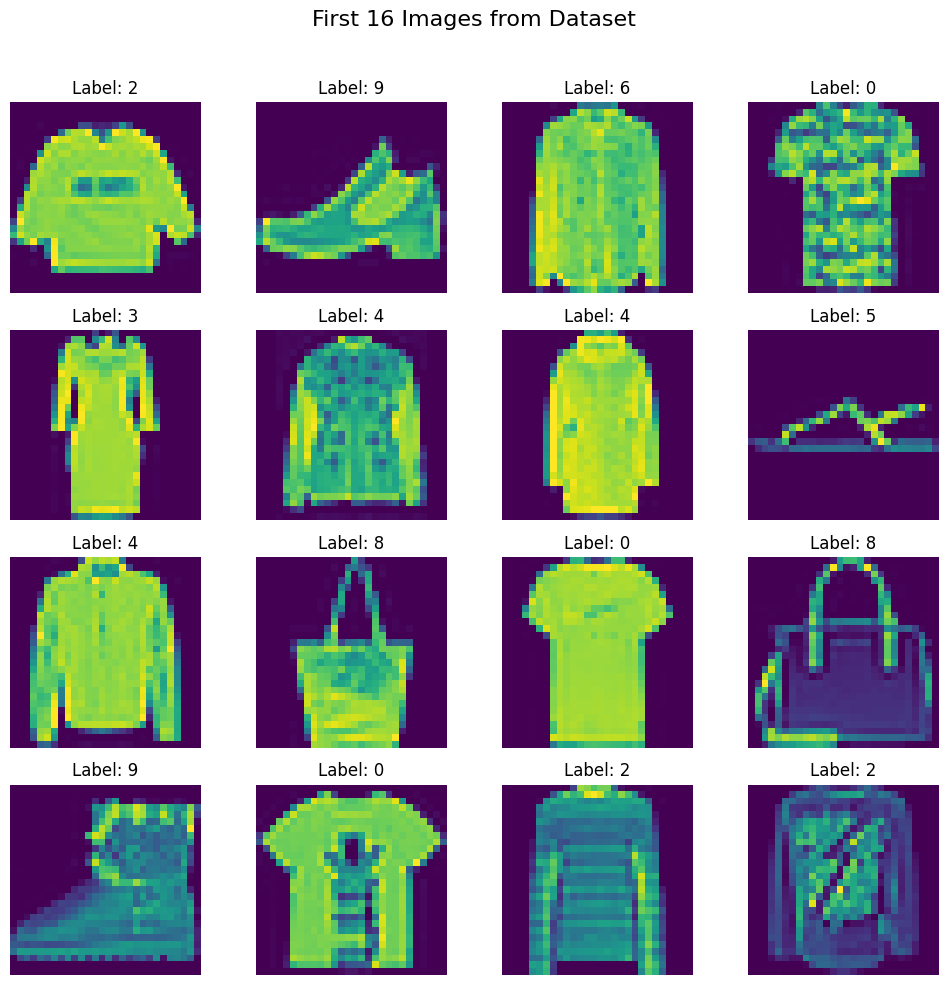

In [7]:
# create a 4x4 grid of images from the dataset
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('First 16 Images from Dataset',fontsize=16)
for i,ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
x = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:
x_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

In [12]:
# Create a CustomDataset Class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [13]:
# Create train dataset
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test, y_test)

In [14]:
# Create train and test loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [15]:
# Define NN Class
# Implementing Batch Normalization, L2 Regularization and Dropout
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        x = self.model(x)
        return x

In [16]:
# set learning rate and epochs
learning_rate = 0.1
epochs = 100

In [17]:
# Instantiate the model
model = MyNN(x_train.shape[1])
model = model.to(device)
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
# using L2 regularization
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)


In [18]:
# Training loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        # move data to device
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        # Forward pass
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()
        total_epoch_loss = total_epoch_loss+loss.item()
    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_epoch_loss:.4f}')
        
    

Epoch [1/100], Loss: 0.6250
Epoch [2/100], Loss: 0.4923
Epoch [3/100], Loss: 0.4559
Epoch [4/100], Loss: 0.4335
Epoch [5/100], Loss: 0.4170
Epoch [6/100], Loss: 0.4060
Epoch [7/100], Loss: 0.3943
Epoch [8/100], Loss: 0.3862
Epoch [9/100], Loss: 0.3739
Epoch [10/100], Loss: 0.3703
Epoch [11/100], Loss: 0.3666
Epoch [12/100], Loss: 0.3567
Epoch [13/100], Loss: 0.3488
Epoch [14/100], Loss: 0.3467
Epoch [15/100], Loss: 0.3457
Epoch [16/100], Loss: 0.3378
Epoch [17/100], Loss: 0.3324
Epoch [18/100], Loss: 0.3308
Epoch [19/100], Loss: 0.3307
Epoch [20/100], Loss: 0.3250
Epoch [21/100], Loss: 0.3203
Epoch [22/100], Loss: 0.3192
Epoch [23/100], Loss: 0.3225
Epoch [24/100], Loss: 0.3142
Epoch [25/100], Loss: 0.3132
Epoch [26/100], Loss: 0.3154
Epoch [27/100], Loss: 0.3085
Epoch [28/100], Loss: 0.3074
Epoch [29/100], Loss: 0.3034
Epoch [30/100], Loss: 0.3020
Epoch [31/100], Loss: 0.3036
Epoch [32/100], Loss: 0.2980
Epoch [33/100], Loss: 0.2977
Epoch [34/100], Loss: 0.3022
Epoch [35/100], Loss: 0

In [19]:
# set model to evaluation mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [20]:
# Evaluation code

with torch.no_grad():
    total = 0
    correct = 0
    for batch_features, batch_labels in test_loader:
        # move data to device
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f'Accuracy: {100 * correct / total}%')




Accuracy: 89.44166666666666%


In [21]:
# Evaluation code

with torch.no_grad():
    total = 0
    correct = 0
    for batch_features, batch_labels in train_loader:
        # move data to device
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f'Accuracy: {100 * correct / total}%')
# Shows overfitting

Accuracy: 94.63541666666667%


In [38]:
len(test_loader)

38

In [39]:
len(train_loader)

150